Packages loaded successfully.
Final dataset directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/finals

Test output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test
Required inputs found.

Matching table loaded.
Number of matches: 260
Number of treatment sites: 26

Controls per treatment:
10    26
Name: count, dtype: int64

Treatment selected:
treatment_0001

Matched controls:
01: counterfactual_0001_01
02: counterfactual_0001_02
03: counterfactual_0001_03
04: counterfactual_0001_04
05: counterfactual_0001_05
06: counterfactual_0001_06
07: counterfactual_0001_07
08: counterfactual_0001_08
09: counterfactual_0001_09
10: counterfactual_0001_10

Number of controls: 10

Treatment test folder:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001

SENTINEL2

Treatment before:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/finals/sentinel2/treatment/before/treatment_0001_b

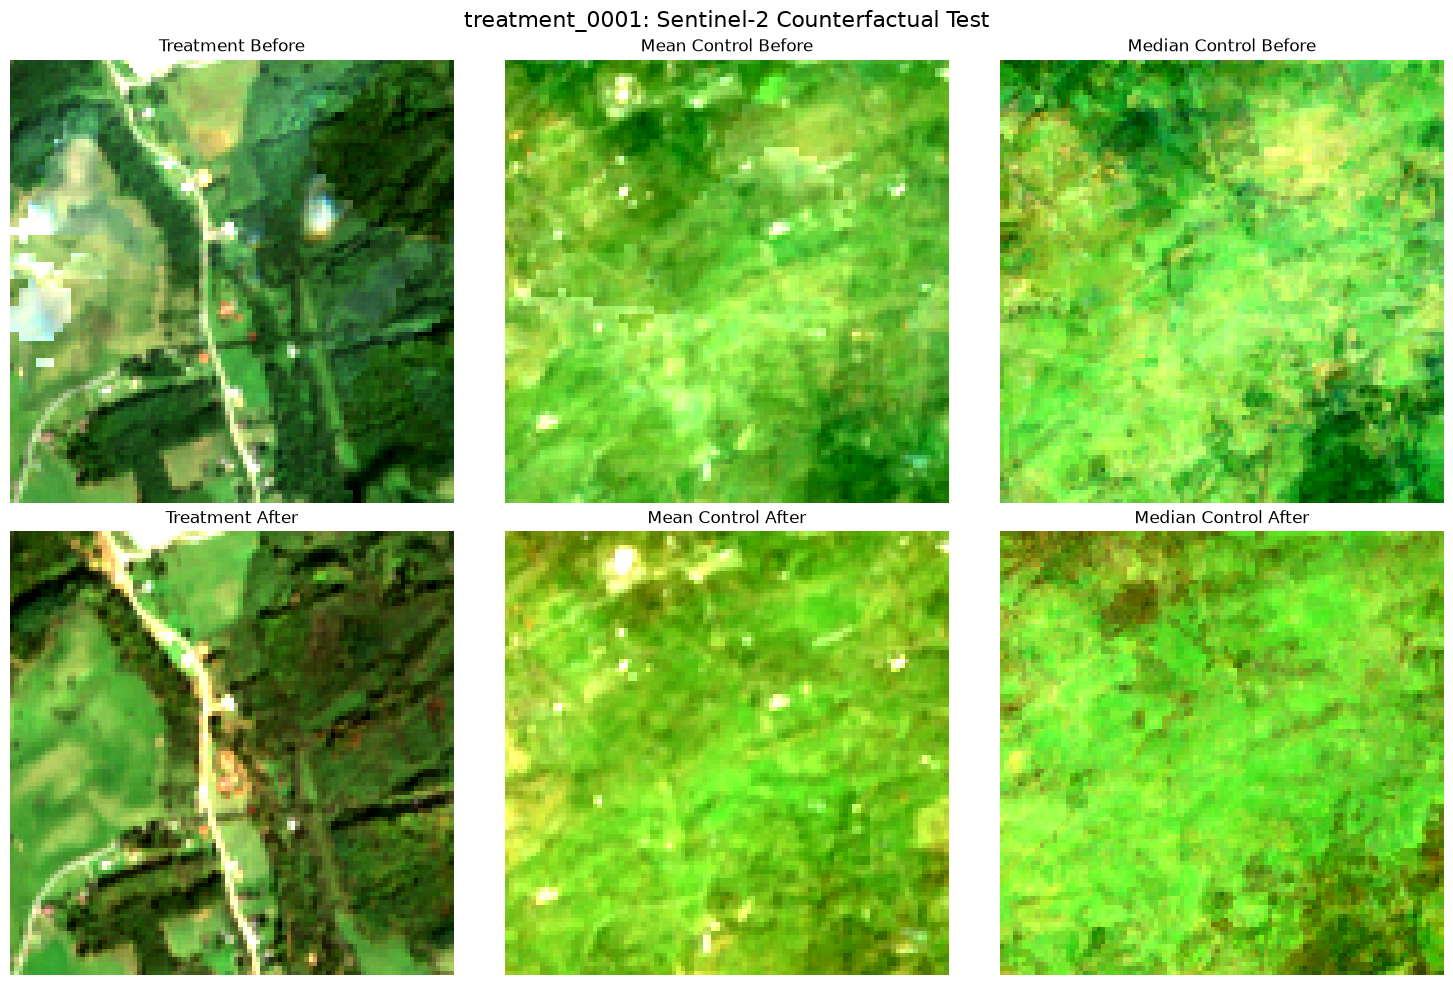


Sentinel-2 comparison saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/sentinel2/comparison.png


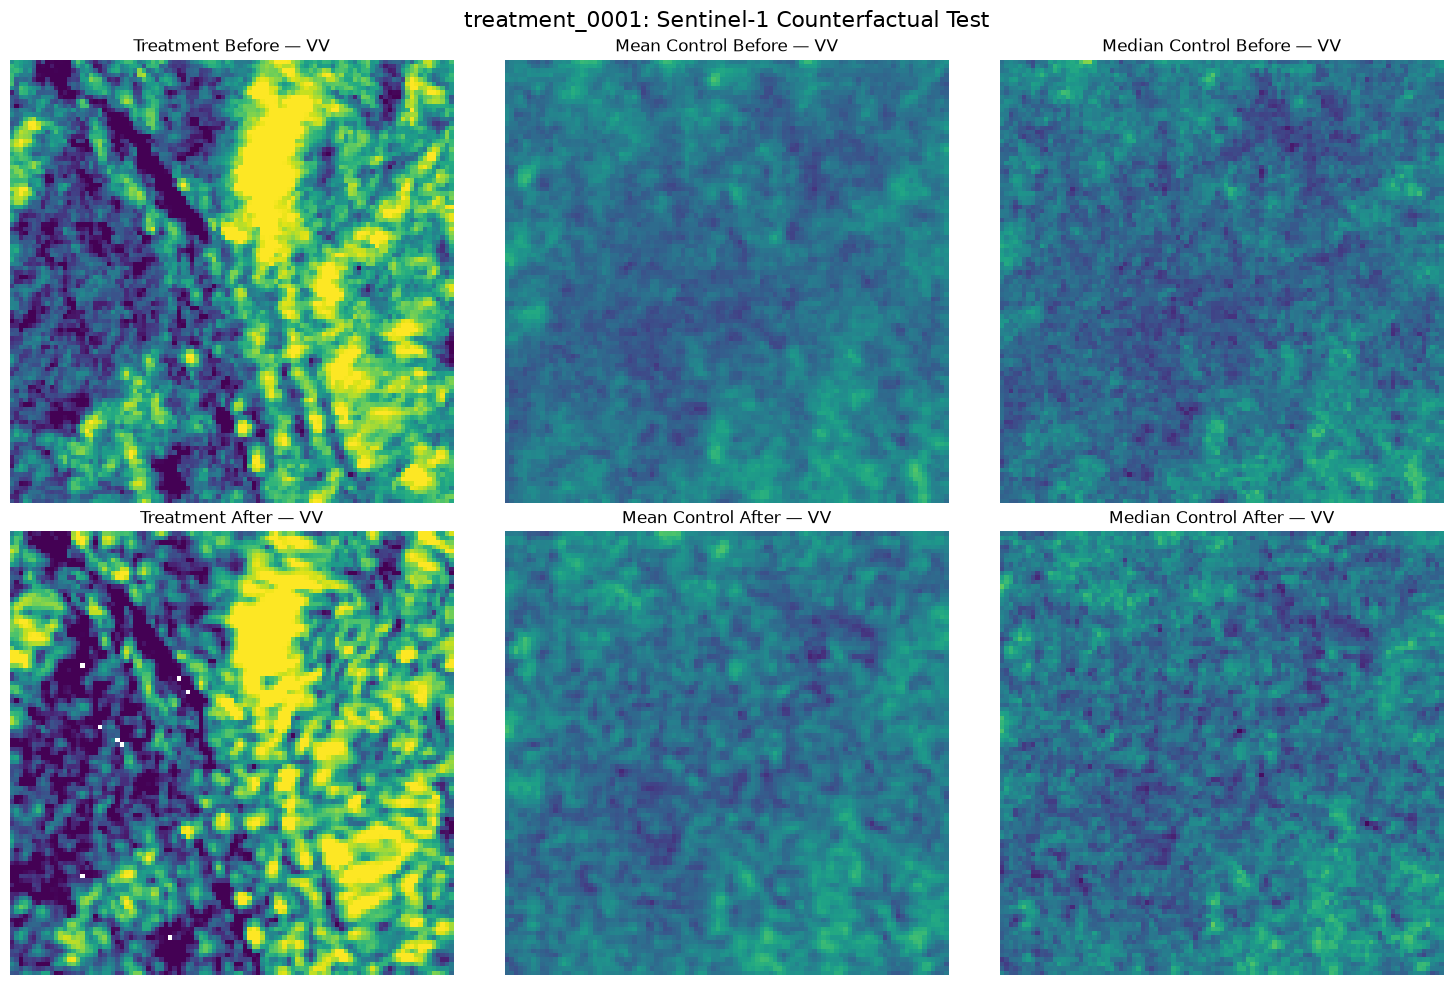


Sentinel-1 comparison saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/sentinel1/comparison.png

COUNTERFACTUAL IMAGE TEST SUMMARY

Treatment site:
treatment_0001

Number of controls used:
10

Output folder:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001

CSV outputs:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/control_image_inventory.csv
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/average_image_summary.csv
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/counterfactual_feature_summary.csv

Sentinel-2 outputs:
mean_control_before → /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/sentinel2/mean_control_before.tif
mean_control_after → /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/treatment_0001/sentin

In [1]:
# =============================================================================
# 09_test_counterfactual_average.ipynb
#
# Purpose:
#
# Test image-based counterfactual construction for ONE treatment site using
# its 10 matched counterfactual sites.
#
# For both Sentinel-2 and Sentinel-1:
#
#   1. Identify 10 controls from site_matching_table.csv
#   2. Load treatment BEFORE and AFTER images
#   3. Load all control BEFORE and AFTER images
#   4. Standardize image shape to the treatment image
#   5. Create pixel-wise mean counterfactual image
#   6. Create pixel-wise median counterfactual image
#   7. Create treatment before-after change image
#   8. Create control before-after change image
#   9. Create adjusted effect image:
#
#        (Treatment_after - Treatment_before)
#        -
#        (Mean_control_after - Mean_control_before)
#
#  10. Save GeoTIFF outputs, PNG comparisons, and CSV summaries
#
# Output:
#
# datasets/test/treatment_XXXX/
#
#   control_image_inventory.csv
#   average_image_summary.csv
#   counterfactual_feature_summary.csv
#
#   sentinel2/
#       mean_control_before.tif
#       mean_control_after.tif
#       median_control_before.tif
#       median_control_after.tif
#       treatment_change.tif
#       mean_control_change.tif
#       median_control_change.tif
#       mean_counterfactual_effect.tif
#       median_counterfactual_effect.tif
#       comparison.png
#
#   sentinel1/
#       same structure
#
# Important:
#
# The 10 controls are different geographic locations.
# Pixel (row, col) is therefore interpreted as the same RELATIVE position
# inside the image chip, not the same real-world coordinate.
# =============================================================================


# =============================================================================
# 1. Load packages
# =============================================================================

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from rasterio.enums import Resampling

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)

print("Packages loaded successfully.")


# =============================================================================
# 2. Define project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

FINALS_DIR = BASE_DIR / "finals"

TEST_DIR = BASE_DIR / "test"

SENTINEL2_DIR = (
    FINALS_DIR /
    "sentinel2"
)

SENTINEL1_DIR = (
    FINALS_DIR /
    "sentinel1"
)

MATCHING_TABLE_FILE = (
    FINALS_DIR /
    "site_matching_table.csv"
)

TEST_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Final dataset directory:")
print(FINALS_DIR)

print("\nTest output directory:")
print(TEST_DIR)


# =============================================================================
# 3. Check required inputs
# =============================================================================

if not MATCHING_TABLE_FILE.exists():

    raise FileNotFoundError(
        "Matching table not found:\n"
        f"{MATCHING_TABLE_FILE}\n\n"
        "Run 06_create_sites.ipynb first."
    )

if not SENTINEL2_DIR.exists():

    raise FileNotFoundError(
        "Sentinel-2 directory not found:\n"
        f"{SENTINEL2_DIR}"
    )

if not SENTINEL1_DIR.exists():

    raise FileNotFoundError(
        "Sentinel-1 directory not found:\n"
        f"{SENTINEL1_DIR}"
    )

print("Required inputs found.")


# =============================================================================
# 4. Load treatment-control matching table
# =============================================================================

matching_table = pd.read_csv(
    MATCHING_TABLE_FILE
)

required_matching_columns = [
    "treatment_site_id",
    "counterfactual_site_id",
]

missing_matching_columns = [
    column
    for column in required_matching_columns
    if column not in matching_table.columns
]

if missing_matching_columns:

    raise ValueError(
        "Matching table is missing columns:\n"
        f"{missing_matching_columns}"
    )

print("\nMatching table loaded.")

print(
    "Number of matches:",
    len(matching_table),
)

print(
    "Number of treatment sites:",
    matching_table[
        "treatment_site_id"
    ].nunique(),
)

print("\nControls per treatment:")

print(
    matching_table
    .groupby(
        "treatment_site_id"
    )
    .size()
    .value_counts()
    .sort_index()
)


# =============================================================================
# 5. Select ONE treatment site for testing
#
# Change this if you want another site:
#
# TEST_TREATMENT_ID = "treatment_0005"
#
# Leave None to automatically select first treatment.
# =============================================================================

TEST_TREATMENT_ID = None

available_treatments = sorted(
    matching_table[
        "treatment_site_id"
    ]
    .dropna()
    .astype(str)
    .unique()
)

if not available_treatments:

    raise RuntimeError(
        "No treatment sites found in matching table."
    )

if TEST_TREATMENT_ID is None:

    TEST_TREATMENT_ID = (
        available_treatments[0]
    )

if (
    TEST_TREATMENT_ID
    not in available_treatments
):

    raise ValueError(
        f"{TEST_TREATMENT_ID} is not present "
        "in site_matching_table.csv"
    )

print("\nTreatment selected:")
print(TEST_TREATMENT_ID)


# =============================================================================
# 6. Get the 10 matched controls
# =============================================================================

test_matches = (
    matching_table
    .loc[
        matching_table[
            "treatment_site_id"
        ].astype(str)
        ==
        TEST_TREATMENT_ID
    ]
    .copy()
)

if "control_rank" in test_matches.columns:

    test_matches = (
        test_matches
        .sort_values(
            "control_rank"
        )
    )

control_ids = (
    test_matches[
        "counterfactual_site_id"
    ]
    .astype(str)
    .tolist()
)

print("\nMatched controls:")

for rank, control_id in enumerate(
    control_ids,
    start=1,
):

    print(
        f"{rank:02d}: {control_id}"
    )

print(
    "\nNumber of controls:",
    len(control_ids),
)

if len(control_ids) != 10:

    raise RuntimeError(
        f"{TEST_TREATMENT_ID} has "
        f"{len(control_ids)} controls instead of 10."
    )


# =============================================================================
# 7. Create output directories
# =============================================================================

TREATMENT_TEST_DIR = (
    TEST_DIR /
    TEST_TREATMENT_ID
)

S2_TEST_DIR = (
    TREATMENT_TEST_DIR /
    "sentinel2"
)

S1_TEST_DIR = (
    TREATMENT_TEST_DIR /
    "sentinel1"
)

for folder in [
    TREATMENT_TEST_DIR,
    S2_TEST_DIR,
    S1_TEST_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("\nTreatment test folder:")
print(TREATMENT_TEST_DIR)


# =============================================================================
# 8. Define band labels and descriptions
# =============================================================================

BAND_METADATA = {

    "sentinel2": {

        "B2": {
            "label": "Blue",
            "description": (
                "Blue visible-light reflectance; useful for water, "
                "haze, and natural-color imagery."
            ),
        },

        "B3": {
            "label": "Green",
            "description": (
                "Green visible-light reflectance; useful for vegetation "
                "and water-related analysis."
            ),
        },

        "B4": {
            "label": "Red",
            "description": (
                "Red visible-light reflectance; commonly used with NIR "
                "to measure vegetation condition."
            ),
        },

        "B8": {
            "label": "Near Infrared (NIR)",
            "description": (
                "Near-infrared reflectance; strongly related to healthy "
                "vegetation and canopy condition."
            ),
        },

        "B11": {
            "label": "Shortwave Infrared 1 (SWIR1)",
            "description": (
                "Shortwave infrared reflectance; sensitive to vegetation "
                "moisture, soil moisture, and exposed surfaces."
            ),
        },

        "B12": {
            "label": "Shortwave Infrared 2 (SWIR2)",
            "description": (
                "Shortwave infrared reflectance; useful for surface disturbance, "
                "exposed soil, moisture change, and burn-related changes."
            ),
        },

        "NDVI": {
            "label": "Normalized Difference Vegetation Index",
            "description": (
                "Vegetation index calculated from NIR and red bands; "
                "higher values generally indicate healthier or denser vegetation."
            ),
        },

        "NDWI": {
            "label": "Normalized Difference Water Index",
            "description": (
                "Water and wetness index calculated from green and NIR bands; "
                "useful for identifying surface water and moisture changes."
            ),
        },

    },

    "sentinel1": {

        "VV": {
            "label": "VV Backscatter",
            "description": (
                "Radar backscatter with vertical transmit and vertical receive "
                "polarization; sensitive to surface roughness, moisture, "
                "and structural changes."
            ),
        },

        "VH": {
            "label": "VH Backscatter",
            "description": (
                "Radar backscatter with vertical transmit and horizontal receive "
                "polarization; particularly sensitive to vegetation structure "
                "and volume scattering."
            ),
        },

        "VV_minus_VH": {
            "label": "VV minus VH",
            "description": (
                "Difference between VV and VH radar backscatter in dB; "
                "useful for characterizing changes in vegetation structure "
                "and surface scattering."
            ),
        },

    },

}


# =============================================================================
# 9. Define sensor configurations
# =============================================================================

SENSOR_CONFIG = {

    "sentinel2": {

        "root": SENTINEL2_DIR,

        "output": S2_TEST_DIR,

        "bands": [
            "B2",
            "B3",
            "B4",
            "B8",
            "B11",
            "B12",
            "NDVI",
            "NDWI",
        ],

    },

    "sentinel1": {

        "root": SENTINEL1_DIR,

        "output": S1_TEST_DIR,

        "bands": [
            "VV",
            "VH",
            "VV_minus_VH",
        ],

    },

}


# =============================================================================
# 10. Helper: find an image file
# =============================================================================

def find_image(
    sensor_root,
    group,
    period,
    site_id,
    sensor_name,
):
    """
    Find one GeoTIFF for the specified site.
    """

    folder = (
        sensor_root /
        group /
        period
    )

    if not folder.exists():

        raise FileNotFoundError(
            f"Folder does not exist:\n{folder}"
        )

    exact_file = (
        folder /
        f"{site_id}_{period}_{sensor_name}.tif"
    )

    if exact_file.exists():

        return exact_file

    matches = sorted(
        folder.glob(
            f"{site_id}*{period}*{sensor_name}*.tif"
        )
    )

    if len(matches) == 0:

        matches = sorted(
            folder.glob(
                f"{site_id}*.tif"
            )
        )

    if len(matches) == 0:

        raise FileNotFoundError(
            "Image not found.\n\n"
            f"Sensor: {sensor_name}\n"
            f"Group: {group}\n"
            f"Period: {period}\n"
            f"Site: {site_id}\n"
            f"Folder: {folder}"
        )

    if len(matches) > 1:

        print(
            f"Warning: multiple images found for {site_id}. "
            f"Using {matches[0].name}"
        )

    return matches[0]


# =============================================================================
# 11. Helper: read raster
# =============================================================================

def read_raster(
    file_path,
    target_height=None,
    target_width=None,
):
    """
    Read raster into:
        bands × height × width

    Masked and NoData values become np.nan.
    """

    file_path = Path(
        file_path
    )

    with rasterio.open(
        file_path
    ) as source:

        original_height = source.height
        original_width = source.width
        original_count = source.count

        original_crs = str(
            source.crs
        )

        original_resolution = (
            source.res
        )

        if (
            target_height is None
            or target_width is None
        ):

            data = source.read(
                masked=True
            )

        else:

            data = source.read(
                out_shape=(
                    source.count,
                    target_height,
                    target_width,
                ),
                resampling=Resampling.bilinear,
                masked=True,
            )

        data = (
            data
            .astype(
                "float32"
            )
            .filled(
                np.nan
            )
        )

        profile = (
            source.profile.copy()
        )

    return {

        "data": data,

        "profile": profile,

        "original_height": original_height,

        "original_width": original_width,

        "original_count": original_count,

        "original_crs": original_crs,

        "original_resolution_x": (
            original_resolution[0]
        ),

        "original_resolution_y": (
            original_resolution[1]
        ),

    }


# =============================================================================
# 12. Helper: save raster
# =============================================================================

def save_raster(
    array,
    reference_file,
    output_file,
    band_names,
    description,
):
    """
    Save a synthetic raster using the treatment raster grid.
    """

    output_file = Path(
        output_file
    )

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with rasterio.open(
        reference_file
    ) as reference:

        profile = (
            reference.profile.copy()
        )

    profile.update(
        {
            "count": array.shape[0],
            "height": array.shape[1],
            "width": array.shape[2],
            "dtype": "float32",
            "nodata": np.nan,
            "compress": "lzw",
        }
    )

    with rasterio.open(
        output_file,
        "w",
        **profile,
    ) as destination:

        destination.write(
            array.astype(
                "float32"
            )
        )

        for band_number, band_name in enumerate(
            band_names,
            start=1,
        ):

            destination.set_band_description(
                band_number,
                band_name,
            )

        destination.update_tags(
            description=description,
            synthetic_counterfactual="true",
            treatment_site=TEST_TREATMENT_ID,
            number_of_controls=len(control_ids),
        )

    return output_file


# =============================================================================
# 13. Helper: valid pixel fraction
# =============================================================================

def valid_pixel_fraction(
    array,
):
    """
    Fraction of pixels containing finite numeric values.
    """

    return float(
        np.isfinite(
            array
        ).mean()
    )


# =============================================================================
# 14. Helper: summarize one multi-band image
# =============================================================================

def summarize_image(
    array,
    sensor,
    period,
    image_type,
    band_names,
    number_of_controls,
):
    """
    Produce one summary row per band.
    """

    records = []

    for band_index, band_name in enumerate(
        band_names
    ):

        band = array[
            band_index
        ]

        metadata = (
            BAND_METADATA[
                sensor
            ][
                band_name
            ]
        )

        valid_values = band[
            np.isfinite(
                band
            )
        ]

        if valid_values.size == 0:

            mean_value = np.nan
            median_value = np.nan
            std_value = np.nan
            min_value = np.nan
            max_value = np.nan

        else:

            mean_value = float(
                np.nanmean(
                    valid_values
                )
            )

            median_value = float(
                np.nanmedian(
                    valid_values
                )
            )

            std_value = float(
                np.nanstd(
                    valid_values
                )
            )

            min_value = float(
                np.nanmin(
                    valid_values
                )
            )

            max_value = float(
                np.nanmax(
                    valid_values
                )
            )

        records.append(
            {
                "treatment_site_id": (
                    TEST_TREATMENT_ID
                ),

                "sensor": sensor,

                "period": period,

                "image_type": image_type,

                "band": band_name,

                "band_label": (
                    metadata[
                        "label"
                    ]
                ),

                "band_description": (
                    metadata[
                        "description"
                    ]
                ),

                "number_of_controls": (
                    number_of_controls
                ),

                "mean_pixel_value": (
                    mean_value
                ),

                "median_pixel_value": (
                    median_value
                ),

                "std_pixel_value": (
                    std_value
                ),

                "min_pixel_value": (
                    min_value
                ),

                "max_pixel_value": (
                    max_value
                ),

                "valid_pixel_fraction": (
                    valid_pixel_fraction(
                        band
                    )
                ),

            }
        )

    return records


# =============================================================================
# 15. Main function: build counterfactual images
# =============================================================================

def build_counterfactual_for_sensor(
    sensor_name,
):
    """
    Build mean and median counterfactual images for one sensor.
    """

    config = SENSOR_CONFIG[
        sensor_name
    ]

    sensor_root = config[
        "root"
    ]

    output_dir = config[
        "output"
    ]

    band_names = config[
        "bands"
    ]

    print(
        "\n"
        + "=" * 78
    )

    print(
        sensor_name.upper()
    )

    print(
        "=" * 78
    )


    # -------------------------------------------------------------------------
    # Treatment files
    # -------------------------------------------------------------------------

    treatment_before_file = find_image(
        sensor_root=sensor_root,
        group="treatment",
        period="before",
        site_id=TEST_TREATMENT_ID,
        sensor_name=sensor_name,
    )

    treatment_after_file = find_image(
        sensor_root=sensor_root,
        group="treatment",
        period="after",
        site_id=TEST_TREATMENT_ID,
        sensor_name=sensor_name,
    )

    print("\nTreatment before:")
    print(treatment_before_file)

    print("\nTreatment after:")
    print(treatment_after_file)


    # -------------------------------------------------------------------------
    # Read treatment reference
    # -------------------------------------------------------------------------

    treatment_before = read_raster(
        treatment_before_file
    )

    target_height = (
        treatment_before[
            "data"
        ].shape[1]
    )

    target_width = (
        treatment_before[
            "data"
        ].shape[2]
    )

    treatment_after = read_raster(
        treatment_after_file,
        target_height=target_height,
        target_width=target_width,
    )

    if (
        treatment_before[
            "data"
        ].shape[0]
        !=
        len(band_names)
    ):

        raise RuntimeError(
            f"{sensor_name} treatment BEFORE image has "
            f"{treatment_before['data'].shape[0]} bands, "
            f"expected {len(band_names)}."
        )


    # -------------------------------------------------------------------------
    # Load controls
    # -------------------------------------------------------------------------

    control_before_arrays = []

    control_after_arrays = []

    control_inventory_records = []

    for control_rank, control_id in enumerate(
        control_ids,
        start=1,
    ):

        before_file = find_image(
            sensor_root=sensor_root,
            group="counterfactual",
            period="before",
            site_id=control_id,
            sensor_name=sensor_name,
        )

        after_file = find_image(
            sensor_root=sensor_root,
            group="counterfactual",
            period="after",
            site_id=control_id,
            sensor_name=sensor_name,
        )

        before_raster = read_raster(
            before_file,
            target_height=target_height,
            target_width=target_width,
        )

        after_raster = read_raster(
            after_file,
            target_height=target_height,
            target_width=target_width,
        )

        if (
            before_raster[
                "data"
            ].shape[0]
            !=
            len(band_names)
        ):

            raise RuntimeError(
                f"Unexpected band count in:\n{before_file}"
            )

        if (
            after_raster[
                "data"
            ].shape[0]
            !=
            len(band_names)
        ):

            raise RuntimeError(
                f"Unexpected band count in:\n{after_file}"
            )

        control_before_arrays.append(
            before_raster[
                "data"
            ]
        )

        control_after_arrays.append(
            after_raster[
                "data"
            ]
        )

        matching_row = (
            test_matches.loc[
                test_matches[
                    "counterfactual_site_id"
                ].astype(str)
                ==
                control_id
            ]
        )

        matching_information = {}

        if not matching_row.empty:

            matching_information = (
                matching_row
                .iloc[0]
                .to_dict()
            )

        control_inventory_records.append(
            {
                "sensor": (
                    sensor_name
                ),

                "treatment_site_id": (
                    TEST_TREATMENT_ID
                ),

                "control_rank": (
                    matching_information.get(
                        "control_rank",
                        control_rank,
                    )
                ),

                "counterfactual_site_id": (
                    control_id
                ),

                "pair_id": (
                    matching_information.get(
                        "pair_id",
                        None,
                    )
                ),

                "match_quality": (
                    matching_information.get(
                        "match_quality",
                        None,
                    )
                ),

                "distance_km": (
                    matching_information.get(
                        "distance_km",
                        None,
                    )
                ),

                "elevation_difference_m": (
                    matching_information.get(
                        "elevation_difference_m",
                        None,
                    )
                ),

                "slope_difference_deg": (
                    matching_information.get(
                        "slope_difference_deg",
                        None,
                    )
                ),

                "before_file": str(
                    before_file
                ),

                "after_file": str(
                    after_file
                ),

                "before_band_count": (
                    before_raster[
                        "original_count"
                    ]
                ),

                "after_band_count": (
                    after_raster[
                        "original_count"
                    ]
                ),

                "before_height": (
                    before_raster[
                        "original_height"
                    ]
                ),

                "before_width": (
                    before_raster[
                        "original_width"
                    ]
                ),

                "after_height": (
                    after_raster[
                        "original_height"
                    ]
                ),

                "after_width": (
                    after_raster[
                        "original_width"
                    ]
                ),

                "crs": (
                    before_raster[
                        "original_crs"
                    ]
                ),

                "resolution_x": (
                    before_raster[
                        "original_resolution_x"
                    ]
                ),

                "resolution_y": (
                    before_raster[
                        "original_resolution_y"
                    ]
                ),

                "before_valid_pixel_fraction": (
                    valid_pixel_fraction(
                        before_raster[
                            "data"
                        ]
                    )
                ),

                "after_valid_pixel_fraction": (
                    valid_pixel_fraction(
                        after_raster[
                            "data"
                        ]
                    )
                ),
            }
        )


    # -------------------------------------------------------------------------
    # Stack controls
    # -------------------------------------------------------------------------

    controls_before = np.stack(
        control_before_arrays,
        axis=0,
    )

    controls_after = np.stack(
        control_after_arrays,
        axis=0,
    )

    print("\nControl BEFORE stack:")
    print(controls_before.shape)

    print("\nControl AFTER stack:")
    print(controls_after.shape)


    # -------------------------------------------------------------------------
    # Mean counterfactual
    # -------------------------------------------------------------------------

    mean_control_before = np.nanmean(
        controls_before,
        axis=0,
    )

    mean_control_after = np.nanmean(
        controls_after,
        axis=0,
    )


    # -------------------------------------------------------------------------
    # Median counterfactual
    # -------------------------------------------------------------------------

    median_control_before = np.nanmedian(
        controls_before,
        axis=0,
    )

    median_control_after = np.nanmedian(
        controls_after,
        axis=0,
    )


    # -------------------------------------------------------------------------
    # Change images
    # -------------------------------------------------------------------------

    treatment_change = (
        treatment_after[
            "data"
        ]
        -
        treatment_before[
            "data"
        ]
    )

    mean_control_change = (
        mean_control_after
        -
        mean_control_before
    )

    median_control_change = (
        median_control_after
        -
        median_control_before
    )


    # -------------------------------------------------------------------------
    # Adjusted effects
    # -------------------------------------------------------------------------

    mean_counterfactual_effect = (
        treatment_change
        -
        mean_control_change
    )

    median_counterfactual_effect = (
        treatment_change
        -
        median_control_change
    )


    # -------------------------------------------------------------------------
    # Save GeoTIFFs
    # -------------------------------------------------------------------------

    output_files = {}

    output_files[
        "mean_control_before"
    ] = save_raster(
        mean_control_before,
        treatment_before_file,
        output_dir /
        "mean_control_before.tif",
        band_names,
        (
            "Pixel-wise mean of 10 matched "
            "counterfactual BEFORE images"
        ),
    )

    output_files[
        "mean_control_after"
    ] = save_raster(
        mean_control_after,
        treatment_before_file,
        output_dir /
        "mean_control_after.tif",
        band_names,
        (
            "Pixel-wise mean of 10 matched "
            "counterfactual AFTER images"
        ),
    )

    output_files[
        "median_control_before"
    ] = save_raster(
        median_control_before,
        treatment_before_file,
        output_dir /
        "median_control_before.tif",
        band_names,
        (
            "Pixel-wise median of 10 matched "
            "counterfactual BEFORE images"
        ),
    )

    output_files[
        "median_control_after"
    ] = save_raster(
        median_control_after,
        treatment_before_file,
        output_dir /
        "median_control_after.tif",
        band_names,
        (
            "Pixel-wise median of 10 matched "
            "counterfactual AFTER images"
        ),
    )

    output_files[
        "treatment_change"
    ] = save_raster(
        treatment_change,
        treatment_before_file,
        output_dir /
        "treatment_change.tif",
        band_names,
        (
            "Treatment AFTER minus BEFORE"
        ),
    )

    output_files[
        "mean_control_change"
    ] = save_raster(
        mean_control_change,
        treatment_before_file,
        output_dir /
        "mean_control_change.tif",
        band_names,
        (
            "Mean control AFTER minus BEFORE"
        ),
    )

    output_files[
        "median_control_change"
    ] = save_raster(
        median_control_change,
        treatment_before_file,
        output_dir /
        "median_control_change.tif",
        band_names,
        (
            "Median control AFTER minus BEFORE"
        ),
    )

    output_files[
        "mean_counterfactual_effect"
    ] = save_raster(
        mean_counterfactual_effect,
        treatment_before_file,
        output_dir /
        "mean_counterfactual_effect.tif",
        band_names,
        (
            "Treatment change minus "
            "mean-control change"
        ),
    )

    output_files[
        "median_counterfactual_effect"
    ] = save_raster(
        median_counterfactual_effect,
        treatment_before_file,
        output_dir /
        "median_counterfactual_effect.tif",
        band_names,
        (
            "Treatment change minus "
            "median-control change"
        ),
    )


    # -------------------------------------------------------------------------
    # Average image summaries
    # -------------------------------------------------------------------------

    average_image_summary_records = []

    average_image_summary_records.extend(
        summarize_image(
            array=mean_control_before,
            sensor=sensor_name,
            period="before",
            image_type="mean_control",
            band_names=band_names,
            number_of_controls=10,
        )
    )

    average_image_summary_records.extend(
        summarize_image(
            array=mean_control_after,
            sensor=sensor_name,
            period="after",
            image_type="mean_control",
            band_names=band_names,
            number_of_controls=10,
        )
    )

    average_image_summary_records.extend(
        summarize_image(
            array=median_control_before,
            sensor=sensor_name,
            period="before",
            image_type="median_control",
            band_names=band_names,
            number_of_controls=10,
        )
    )

    average_image_summary_records.extend(
        summarize_image(
            array=median_control_after,
            sensor=sensor_name,
            period="after",
            image_type="median_control",
            band_names=band_names,
            number_of_controls=10,
        )
    )


    # -------------------------------------------------------------------------
    # Treatment-control feature comparison
    # -------------------------------------------------------------------------

    feature_records = []

    for band_index, band_name in enumerate(
        band_names
    ):

        metadata = (
            BAND_METADATA[
                sensor_name
            ][
                band_name
            ]
        )

        treatment_before_band = (
            treatment_before[
                "data"
            ][band_index]
        )

        treatment_after_band = (
            treatment_after[
                "data"
            ][band_index]
        )

        mean_before_band = (
            mean_control_before[
                band_index
            ]
        )

        mean_after_band = (
            mean_control_after[
                band_index
            ]
        )

        median_before_band = (
            median_control_before[
                band_index
            ]
        )

        median_after_band = (
            median_control_after[
                band_index
            ]
        )

        treatment_change_band = (
            treatment_change[
                band_index
            ]
        )

        mean_control_change_band = (
            mean_control_change[
                band_index
            ]
        )

        median_control_change_band = (
            median_control_change[
                band_index
            ]
        )

        mean_effect_band = (
            mean_counterfactual_effect[
                band_index
            ]
        )

        median_effect_band = (
            median_counterfactual_effect[
                band_index
            ]
        )

        feature_records.append(
            {
                "treatment_site_id": (
                    TEST_TREATMENT_ID
                ),

                "sensor": (
                    sensor_name
                ),

                "band": (
                    band_name
                ),

                "band_label": (
                    metadata[
                        "label"
                    ]
                ),

                "band_description": (
                    metadata[
                        "description"
                    ]
                ),

                "number_of_controls": 10,

                "treatment_before_mean": (
                    float(
                        np.nanmean(
                            treatment_before_band
                        )
                    )
                ),

                "treatment_after_mean": (
                    float(
                        np.nanmean(
                            treatment_after_band
                        )
                    )
                ),

                "treatment_change_mean": (
                    float(
                        np.nanmean(
                            treatment_change_band
                        )
                    )
                ),

                "mean_control_before_mean": (
                    float(
                        np.nanmean(
                            mean_before_band
                        )
                    )
                ),

                "mean_control_after_mean": (
                    float(
                        np.nanmean(
                            mean_after_band
                        )
                    )
                ),

                "mean_control_change_mean": (
                    float(
                        np.nanmean(
                            mean_control_change_band
                        )
                    )
                ),

                "mean_adjusted_effect": (
                    float(
                        np.nanmean(
                            mean_effect_band
                        )
                    )
                ),

                "median_control_before_mean": (
                    float(
                        np.nanmean(
                            median_before_band
                        )
                    )
                ),

                "median_control_after_mean": (
                    float(
                        np.nanmean(
                            median_after_band
                        )
                    )
                ),

                "median_control_change_mean": (
                    float(
                        np.nanmean(
                            median_control_change_band
                        )
                    )
                ),

                "median_adjusted_effect": (
                    float(
                        np.nanmean(
                            median_effect_band
                        )
                    )
                ),

                "treatment_before_valid_fraction": (
                    valid_pixel_fraction(
                        treatment_before_band
                    )
                ),

                "treatment_after_valid_fraction": (
                    valid_pixel_fraction(
                        treatment_after_band
                    )
                ),

                "mean_control_before_valid_fraction": (
                    valid_pixel_fraction(
                        mean_before_band
                    )
                ),

                "mean_control_after_valid_fraction": (
                    valid_pixel_fraction(
                        mean_after_band
                    )
                ),

            }
        )


    return {

        "sensor": (
            sensor_name
        ),

        "band_names": (
            band_names
        ),

        "treatment_before": (
            treatment_before[
                "data"
            ]
        ),

        "treatment_after": (
            treatment_after[
                "data"
            ]
        ),

        "mean_before": (
            mean_control_before
        ),

        "mean_after": (
            mean_control_after
        ),

        "median_before": (
            median_control_before
        ),

        "median_after": (
            median_control_after
        ),

        "treatment_change": (
            treatment_change
        ),

        "mean_control_change": (
            mean_control_change
        ),

        "median_control_change": (
            median_control_change
        ),

        "mean_effect": (
            mean_counterfactual_effect
        ),

        "median_effect": (
            median_counterfactual_effect
        ),

        "control_inventory": (
            pd.DataFrame(
                control_inventory_records
            )
        ),

        "average_summary": (
            pd.DataFrame(
                average_image_summary_records
            )
        ),

        "feature_summary": (
            pd.DataFrame(
                feature_records
            )
        ),

        "outputs": (
            output_files
        ),

    }


# =============================================================================
# 16. Run Sentinel-2
# =============================================================================

sentinel2_result = (
    build_counterfactual_for_sensor(
        "sentinel2"
    )
)

print(
    "\nSentinel-2 processing completed."
)


# =============================================================================
# 17. Run Sentinel-1
# =============================================================================

sentinel1_result = (
    build_counterfactual_for_sensor(
        "sentinel1"
    )
)

print(
    "\nSentinel-1 processing completed."
)


# =============================================================================
# 18. Save control_image_inventory.csv
# =============================================================================

control_image_inventory = pd.concat(
    [
        sentinel2_result[
            "control_inventory"
        ],
        sentinel1_result[
            "control_inventory"
        ],
    ],
    ignore_index=True,
)

CONTROL_IMAGE_INVENTORY_FILE = (
    TREATMENT_TEST_DIR /
    "control_image_inventory.csv"
)

control_image_inventory.to_csv(
    CONTROL_IMAGE_INVENTORY_FILE,
    index=False,
)

print(
    "\nControl image inventory saved to:"
)

print(
    CONTROL_IMAGE_INVENTORY_FILE
)


# =============================================================================
# 19. Save average_image_summary.csv
# =============================================================================

average_image_summary = pd.concat(
    [
        sentinel2_result[
            "average_summary"
        ],
        sentinel1_result[
            "average_summary"
        ],
    ],
    ignore_index=True,
)

AVERAGE_IMAGE_SUMMARY_FILE = (
    TREATMENT_TEST_DIR /
    "average_image_summary.csv"
)

average_image_summary.to_csv(
    AVERAGE_IMAGE_SUMMARY_FILE,
    index=False,
)

print(
    "\nAverage image summary saved to:"
)

print(
    AVERAGE_IMAGE_SUMMARY_FILE
)

print(
    "\nAverage image summary:"
)

print(
    average_image_summary
)


# =============================================================================
# 20. Save counterfactual_feature_summary.csv
# =============================================================================

counterfactual_feature_summary = pd.concat(
    [
        sentinel2_result[
            "feature_summary"
        ],
        sentinel1_result[
            "feature_summary"
        ],
    ],
    ignore_index=True,
)

COUNTERFACTUAL_FEATURE_SUMMARY_FILE = (
    TREATMENT_TEST_DIR /
    "counterfactual_feature_summary.csv"
)

counterfactual_feature_summary.to_csv(
    COUNTERFACTUAL_FEATURE_SUMMARY_FILE,
    index=False,
)

print(
    "\nCounterfactual feature summary saved to:"
)

print(
    COUNTERFACTUAL_FEATURE_SUMMARY_FILE
)

print(
    "\nCounterfactual feature summary:"
)

print(
    counterfactual_feature_summary
)


# =============================================================================
# 21. Sentinel-2 RGB helper
# =============================================================================

def create_sentinel2_rgb(
    array,
):
    """
    Create natural-color RGB image.

    B2 = Blue
    B3 = Green
    B4 = Red
    """

    blue = array[0]
    green = array[1]
    red = array[2]

    rgb = np.stack(
        [
            red,
            green,
            blue,
        ],
        axis=-1,
    )

    valid = rgb[
        np.isfinite(
            rgb
        )
    ]

    if valid.size == 0:

        return np.zeros(
            rgb.shape,
            dtype="float32",
        )

    lower = np.nanpercentile(
        valid,
        2,
    )

    upper = np.nanpercentile(
        valid,
        98,
    )

    if upper <= lower:

        upper = (
            lower +
            1e-6
        )

    rgb = np.clip(
        (
            rgb -
            lower
        )
        /
        (
            upper -
            lower
        ),
        0,
        1,
    )

    rgb[
        ~np.isfinite(
            rgb
        )
    ] = 0

    return rgb


# =============================================================================
# 22. Create Sentinel-2 comparison image
# =============================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)

s2_images = [

    (
        sentinel2_result[
            "treatment_before"
        ],
        "Treatment Before",
    ),

    (
        sentinel2_result[
            "mean_before"
        ],
        "Mean Control Before",
    ),

    (
        sentinel2_result[
            "median_before"
        ],
        "Median Control Before",
    ),

    (
        sentinel2_result[
            "treatment_after"
        ],
        "Treatment After",
    ),

    (
        sentinel2_result[
            "mean_after"
        ],
        "Mean Control After",
    ),

    (
        sentinel2_result[
            "median_after"
        ],
        "Median Control After",
    ),

]

for ax, (
    image,
    title,
) in zip(
    axes.ravel(),
    s2_images,
):

    ax.imshow(
        create_sentinel2_rgb(
            image
        )
    )

    ax.set_title(
        title
    )

    ax.axis(
        "off"
    )

fig.suptitle(
    (
        f"{TEST_TREATMENT_ID}: "
        "Sentinel-2 Counterfactual Test"
    ),
    fontsize=16,
)

plt.tight_layout()

S2_COMPARISON_FILE = (
    S2_TEST_DIR /
    "comparison.png"
)

plt.savefig(
    S2_COMPARISON_FILE,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSentinel-2 comparison saved to:"
)

print(
    S2_COMPARISON_FILE
)


# =============================================================================
# 23. Create Sentinel-1 comparison image
# =============================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)

s1_images = [

    (
        sentinel1_result[
            "treatment_before"
        ][0],
        "Treatment Before — VV",
    ),

    (
        sentinel1_result[
            "mean_before"
        ][0],
        "Mean Control Before — VV",
    ),

    (
        sentinel1_result[
            "median_before"
        ][0],
        "Median Control Before — VV",
    ),

    (
        sentinel1_result[
            "treatment_after"
        ][0],
        "Treatment After — VV",
    ),

    (
        sentinel1_result[
            "mean_after"
        ][0],
        "Mean Control After — VV",
    ),

    (
        sentinel1_result[
            "median_after"
        ][0],
        "Median Control After — VV",
    ),

]

valid_s1_arrays = [
    image[
        np.isfinite(
            image
        )
    ]
    for image, _
    in s1_images
    if np.isfinite(
        image
    ).any()
]

if valid_s1_arrays:

    all_s1_values = np.concatenate(
        valid_s1_arrays
    )

    vmin = np.nanpercentile(
        all_s1_values,
        2,
    )

    vmax = np.nanpercentile(
        all_s1_values,
        98,
    )

else:

    vmin = None
    vmax = None

for ax, (
    image,
    title,
) in zip(
    axes.ravel(),
    s1_images,
):

    ax.imshow(
        image,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(
        title
    )

    ax.axis(
        "off"
    )

fig.suptitle(
    (
        f"{TEST_TREATMENT_ID}: "
        "Sentinel-1 Counterfactual Test"
    ),
    fontsize=16,
)

plt.tight_layout()

S1_COMPARISON_FILE = (
    S1_TEST_DIR /
    "comparison.png"
)

plt.savefig(
    S1_COMPARISON_FILE,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSentinel-1 comparison saved to:"
)

print(
    S1_COMPARISON_FILE
)


# =============================================================================
# 24. Final summary
# =============================================================================

print(
    "\n"
    + "=" * 78
)

print(
    "COUNTERFACTUAL IMAGE TEST SUMMARY"
)

print(
    "=" * 78
)

print("\nTreatment site:")
print(TEST_TREATMENT_ID)

print("\nNumber of controls used:")
print(len(control_ids))

print("\nOutput folder:")
print(TREATMENT_TEST_DIR)

print("\nCSV outputs:")

print(
    CONTROL_IMAGE_INVENTORY_FILE
)

print(
    AVERAGE_IMAGE_SUMMARY_FILE
)

print(
    COUNTERFACTUAL_FEATURE_SUMMARY_FILE
)

print("\nSentinel-2 outputs:")

for output_name, output_path in (
    sentinel2_result[
        "outputs"
    ].items()
):

    print(
        output_name,
        "→",
        output_path,
    )

print("\nSentinel-1 outputs:")

for output_name, output_path in (
    sentinel1_result[
        "outputs"
    ].items()
):

    print(
        output_name,
        "→",
        output_path,
    )

print(
    "\nNotebook completed successfully."
)